# Before You Begin

This notebook is made up of two kinds of cells.

📝 **Markdown cells** contain text and instructions.

💻 **Code cells** contain Python code.

To execute either type of cell:

- Click inside the cell.
- Press **Shift + Enter**.

Try it now with the practice code below.

In [3]:
print("Welcome to your biodiversity investigation!")

Welcome to your biodiversity investigation!


# Investigation 1: The Question

## Can citizen science reveal patterns of biodiversity?

The College of Marin has two campuses that differ dramatically in the habitats surrounding them.

- **Indian Valley Campus (IVC)** is surrounded by extensive open space, oak woodland, grassland, and seasonal wetlands.

- **Kentfield Campus** is located near the tidal marshes of Corte Madera Creek and is embedded within a more developed urban landscape.

Ecologists often ask questions like:

- Which habitats support the greatest biodiversity?
- Do different habitats support different biological communities?
- Can we detect these patterns using observations collected by citizen scientists?

In this investigation, you will analyze thousands of wildlife observations submitted to **iNaturalist**, one of the world's largest citizen science projects.

By the end of the notebook, you should be able to answer an important question:

> **Which College of Marin campus is more biodiverse?**

But before looking at the data...

## Make a Prediction

On your worksheet, record your prediction.

- Which campus do you expect to have greater biodiversity?
- Why?
- What evidence or ecological reasoning supports your prediction?

Don't worry about being "right." Scientists often begin investigations by making predictions before collecting evidence.

# Investigation 2: Meet the Dataset

## What information do we have?

The observations used in this activity were downloaded from **iNaturalist**, a citizen science platform where people around the world record observations of living organisms.

Each row in this dataset represents a **single observation** made by an iNaturalist user.

Some observations may represent the same species seen on different days.

Some species may be observed many times.

Others may have been observed only once.

Before we begin our analysis, let's explore the structure of the dataset.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
# Load the dataset

df = pd.read_csv("COM_iNaturalist.csv")

df.head()

,id,observed_on,latitude,longitude,scientific_name,common_name,iconic_taxon_name
0,Kentfield,11/12/11,37.955849,-122.549599,Sequoia sempervirens,coast redwood,Plantae
1,Kentfield,3/13/14,37.956303,-122.549620,Nemophila menziesii,baby blue eyes,Plantae
2,Kentfield,5/19/14,37.950905,-122.545013,Elanus leucurus,White-tailed Kite,Aves
3,Kentfield,10/29/14,37.948170,-122.546112,Harmonia axyridis,Asian Lady Beetle,Insecta
4,Kentfield,9/16/15,37.951425,-122.548267,Ardea alba,Great Egret,Aves


Take a moment to examine the table above.

Notice that each row represents one observation, not one species.

Many observations may belong to the same species.

Others may represent species that appear only once in the entire dataset.

In [14]:
# How many observations are included?

len(df)

1747

Thousands of observations have been collected over many years.

But how many different species do these observations represent?

In [15]:
# How many unique species are represented?

df["scientific_name"].nunique()

526

Now let's examine the variables available in our dataset.

In [16]:
df.columns

Index(['id', 'observed_on', 'latitude', 'longitude', 'scientific_name',
       'common_name', 'iconic_taxon_name'],
      dtype='object')

Each column contains information that may be useful for answering different ecological questions.

Some describe **where** an observation was made.

Others describe **when** it occurred.

Still others identify **what organism** was observed.

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1747 entries, 0 to 1746
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 1747 non-null   object 
 1   observed_on        1747 non-null   object 
 2   latitude           1747 non-null   float64
 3   longitude          1747 non-null   float64
 4   scientific_name    1747 non-null   object 
 5   common_name        1707 non-null   object 
 6   iconic_taxon_name  1747 non-null   object 
dtypes: float64(2), object(5)
memory usage: 61.5+ KB


## Reflection

Before moving on, answer the following questions on your worksheet.

1. What does each row in this dataset represent?

2. Which columns do you think will be most useful for measuring biodiversity?

3. What kinds of information are **not** included in this dataset?

4. Based on what you've seen so far, what challenges might scientists face when using citizen science data to study biodiversity?

# 🌿 Investigation 3: Measuring Biodiversity

Before we compare the two campuses, we need a way to measure biodiversity.

Ecologists use many different measures of biodiversity, but one of the simplest is **species richness**.

Species richness is simply the **number of different species observed** in a particular area.

Notice that species richness does **not** consider how many individuals of each species were observed. A campus with one observation each of 100 species has the same species richness as a campus with 10,000 observations representing those same 100 species.

In this investigation, we will begin by calculating species richness for the entire dataset.

In [18]:
# How many different species are represented in the dataset?

df["scientific_name"].nunique()

526

Great! Now let's ask a slightly different question.

How many species have been observed at **each campus**?

In [19]:
# Count the number of unique species at each campus

df.groupby("id")["scientific_name"].nunique()

id
IVC          321
Kentfield    282
Name: scientific_name, dtype: int64

## 📊 Reflection

Record your answers on your worksheet.

1. How many species have been observed at each campus?

2. Which campus appears to have greater species richness?

3. Does this match your original prediction?

4. Based on these results alone, which campus would you conclude is "more biodiverse"?

At first glance, these results seem to answer our original question.

But scientists rarely stop after a single analysis.

Let's investigate whether another factor could be influencing these results.

# 🌿 Investigation 4: Biodiversity Through Time

The observations in this dataset span many years.

Rather than looking only at total species richness, we can ask another question:

**How has species richness changed over time?**

To answer this question, we first need to extract the year from each observation date.

In [25]:
df["observed_on"] = pd.to_datetime(
    df["observed_on"],
    format="%m/%d/%y"
)

df["Year"] = df["observed_on"].dt.year

df[["observed_on", "Year"]].head()

,observed_on,Year
0,2011-11-12,2011
1,2014-03-13,2014
2,2014-05-19,2014
3,2014-10-29,2014
4,2015-09-16,2015


Now calculate species richness for each campus during each year.

In [26]:
richness = (
    df.groupby(["Year", "id"])["scientific_name"]
      .nunique()
      .reset_index(name="Species_Richness")
)

richness

,Year,id,Species_Richness
0,2010,IVC,2
1,2010,Kentfield,1
2,2011,Kentfield,1
3,2013,IVC,1
4,2014,Kentfield,3
5,2015,IVC,3
6,2015,Kentfield,4
7,2016,IVC,8
8,2017,IVC,22
9,2017,Kentfield,14


Let's visualize these results.

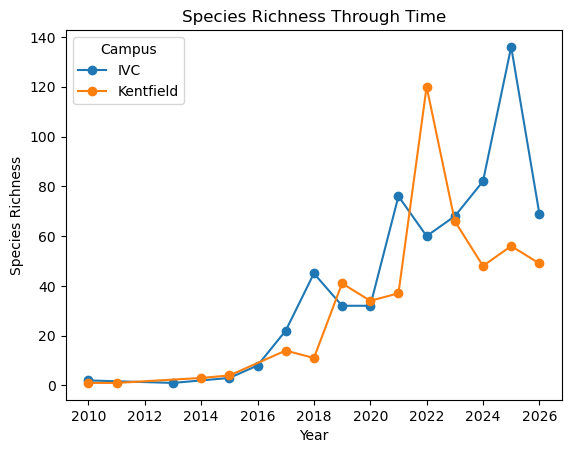

In [27]:
import matplotlib.pyplot as plt

for campus in richness["id"].unique():
    subset = richness[richness["id"] == campus]

    plt.plot(
        subset["Year"],
        subset["Species_Richness"],
        marker="o",
        label=campus
    )

plt.xlabel("Year")
plt.ylabel("Species Richness")
plt.title("Species Richness Through Time")
plt.legend(title="Campus")
plt.show()

## 📊 Reflection

Study the graph carefully.

1. Describe two patterns you observe.

2. Which campus appears to have greater species richness over time?

3. Are there years that stand out as unusual?

4. What biological explanations might account for these patterns?

# 🌿 Investigation 5: Is There More to the Story?

Our graph seems to tell a clear story.

Species richness has increased through time, and one campus appears to support more species than the other.

But before accepting that conclusion, ecologists ask an important question:

> **Could another factor explain this pattern?**

Imagine surveying birds in a forest.

Would you find more species if you spent:

- 10 minutes looking?
- 1 hour looking?
- 10 hours looking?

Probably!

The amount of time spent searching—and the number of observations collected—can strongly influence the number of species that are detected.

Ecologists refer to the amount of searching that goes into collecting observations as **sampling effort**.

Let's investigate whether differences in sampling effort might help explain the patterns we observed.

In [32]:
# Count the number of observations made each year at each campus

observations = (
    df.groupby(["Year", "id"])
      .size()
      .reset_index(name="Observations")
)

observations

,Year,id,Observations
0,2010,IVC,2
1,2010,Kentfield,1
2,2011,Kentfield,1
3,2013,IVC,1
4,2014,Kentfield,3
5,2015,IVC,3
6,2015,Kentfield,4
7,2016,IVC,9
8,2017,IVC,25
9,2017,Kentfield,15


Now let's visualize how observation effort has changed through time.

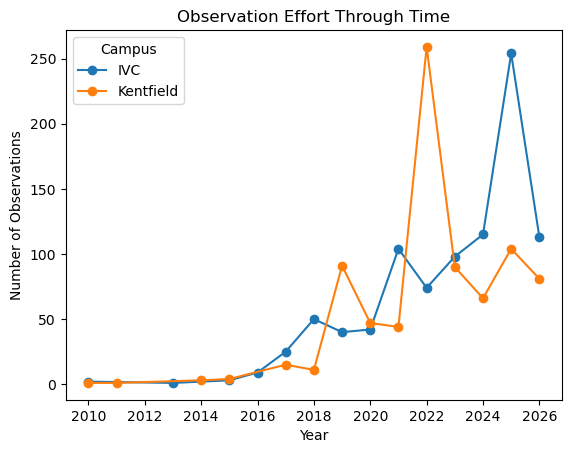

In [33]:
for campus in observations["id"].unique():
    subset = observations[observations["id"] == campus]

    plt.plot(
        subset["Year"],
        subset["Observations"],
        marker="o",
        label=campus
    )

plt.xlabel("Year")
plt.ylabel("Number of Observations")
plt.title("Observation Effort Through Time")
plt.legend(title="Campus")
plt.show()

Interesting...

Do the years with the highest species richness also have the greatest number of observations?

Let's compare these two measurements directly.

In [30]:
comparison = richness.merge(
    observations,
    on=["Year", "id"]
)

comparison.head()

,Year,id,Species_Richness,Observations
0,2010,IVC,2,2
1,2010,Kentfield,1,1
2,2011,Kentfield,1,1
3,2013,IVC,1,1
4,2014,Kentfield,3,3


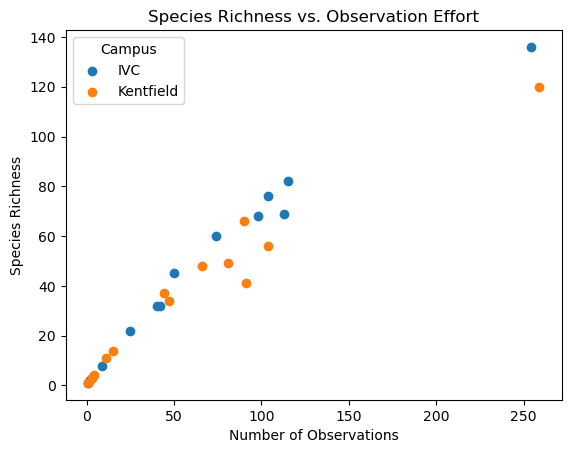

In [31]:
for campus in comparison["id"].unique():
    subset = comparison[comparison["id"] == campus]

    plt.scatter(
        subset["Observations"],
        subset["Species_Richness"],
        label=campus
    )

plt.xlabel("Number of Observations")
plt.ylabel("Species Richness")
plt.title("Species Richness vs. Observation Effort")
plt.legend(title="Campus")
plt.show()

## 📊 Reflection

Answer the following questions on your worksheet.

1. Describe the relationship between observation effort and species richness.

2. Do years with more observations generally include more species?

3. How does this affect your interpretation of the graph from Investigation 4?

4. Why might ecologists be cautious about comparing species richness between years that have very different numbers of observations?

At this point, we have learned something important.

Species richness may depend not only on the organisms present, but also on **how much people looked for them.**

Does that mean our original graph is useless?

Not at all.

It simply means we need to interpret it carefully.

But another question remains.

Even if two campuses have similar numbers of species...

**Are they the same species?**

# 🌿 Investigation 6: Looking More Closely

So far, we have compared the two campuses by measuring **species richness**.

Species richness tells us **how many** different species have been observed.

But imagine two forests that each contain 100 species.

Would those forests necessarily contain the **same** 100 species?

Not at all!

Communities can have similar species richness while supporting very different groups of organisms.

To compare communities, we'll first create a list of all species observed at each campus.

In [50]:
# Create a list of species observed at each campus

ivc_species = set(
    df[df["id"] == "IVC"]["scientific_name"]
)

kentfield_species = set(
    df[df["id"] == "Kentfield"]["scientific_name"]
)
print(f"IVC species: {len(ivc_species)}")
print(f"Kentfield species: {len(kentfield_species)}")

IVC species: 321
Kentfield species: 282


Now let's compare these two species lists.

In [51]:
shared = len(ivc_species & kentfield_species)
ivc_only = len(ivc_species - kentfield_species)
kentfield_only = len(kentfield_species - ivc_species)

print("Shared species:", shared)
print("IVC only:", ivc_only)
print("Kentfield only:", kentfield_only)

Shared species: 77
IVC only: 244
Kentfield only: 205


Interesting...

Although the two campuses have somewhat similar species richness, many species occur at only one campus.

Let's calculate the total number of unique species represented across both campuses.

In [52]:
total_species = len(ivc_species | kentfield_species)


print("Total species:", total_species)


Total species: 526



One commonly used metric is the **Jaccard Similarity Index**, which is calculated as:

\[
\text{Jaccard Similarity} =
\frac{\text{Number of Shared Species}}
{\text{Total Number of Species}}
\]

A value close to **1** indicates that two communities are very similar.

A value close to **0** indicates that they share relatively few species.

> ### 📘 Concept Check: What Does "Similarity" Mean?
>
> When thinking about how similar or different two different habitats might be, Ecologists often summarize community similarity using an **index**. An index is a numerical measure that summarizes one or more characteristics of a system, making it easier to compare different systems.
>
> In ecology, an index often combines information about a biological community into a single value. This makes it easier to compare communities, even when they contain many different species.
>
> Imagine that we create a similarity index that ranges from **0 to 1**.
>
> - If two communities share **all** of their species, what value should the index have?
> - If two communities share **none** of their species, what value should the index have?
>
> A **Jaccard Similarity Index** works this way. The Jaccard Similarity Index is one example of an ecological index. It summarizes the similarity between two communities using a single number between 0 and 1.
>
> - **1.0** = the communities contain exactly the same species
> - **0.0** = the communities share no species
> - Values in between indicate partial overlap
>
> For example:
>
> **High similarity**
>
> Community A: oak, deer, scrub-jay, salamander  
> Community B: oak, deer, scrub-jay, salamander  
>
> Jaccard = **1.0**
>
> **Intermediate similarity**
>
> Community A: oak, deer, scrub-jay, salamander  
> Community B: oak, deer, egret, frog  
>
> Shared species = 2  
> Total species = 6  
> Jaccard = **2 / 6 = 0.33**
>
> **Low similarity**
>
> Community A: oak, deer, scrub-jay, salamander  
> Community B: cattail, pelican, crab, rail  
>
> Jaccard = **0.0**

### 💻 Note About Computational Tools in Biology

Earlier in this investigation, we calculated **species richness** ourselves because it is a relatively simple measurement—the number of unique species observed.

Many ecological analyses, however, involve more complex calculations. Rather than performing these calculations by hand every time, scientists often use **specialized software libraries** that have been developed, tested, and shared by the scientific community.

The **Jaccard Similarity Index** is simple enough that we can calculate it ourselves using Python. Because we understand the formula, we can translate it directly into code.

Notice how the calculation below closely matches the mathematical formula introduced above. As you continue learning Python, you'll discover that many scientific calculations can be expressed just as clearly in code.

Our goal is not simply to obtain a number—it is to understand **what that number means** and determine whether it helps answer our ecological question.

In [49]:
# Calculate the Jaccard Similarity Index
# (Shared species ÷ Total species)

jaccard = shared / total_species

print(f"Jaccard Similarity Index = {jaccard:.3f}")

Jaccard Similarity Index = 0.146


## 📊 Reflection

Record your observations on your worksheet.

1. Were you surprised by the number of shared species?

2. What does the Jaccard Similarity Index suggest about the two campuses?

3. How can two sites have similar species richness but different communities?

4. What ecological factors might explain these differences?

The two campuses appear to support surprisingly different biological communities.

But what kinds of organisms account for these differences?

Let's look more closely at the major groups of organisms represented in the dataset.

# 🌿 Investigation 7: What Makes These Communities Different?

So far, we've learned that the two campuses share relatively few species.

But **what kinds of organisms** account for those differences?

Let's begin by comparing the major taxonomic groups represented in our dataset.

This won't tell us which individual species are present, but it may reveal broader ecological patterns.

In [53]:
# Count the number of unique species in each major taxonomic group

taxa = (
    df.groupby(["id", "iconic_taxon_name"])["scientific_name"]
      .nunique()
      .unstack(fill_value=0)
)

taxa

iconic_taxon_name,Actinopterygii,Amphibia,Animalia,Arachnida,Aves,Chromista,Fungi,Insecta,Mammalia,Mollusca,Plantae,Protozoa,Reptilia
id,,,,,,,,,,,,,
IVC,0,5,3,5,38,0,54,63,8,2,127,4,12
Kentfield,1,1,4,5,57,1,24,44,6,3,131,1,4


## 📊 Reflection

1. Which taxonomic groups contain the greatest number of species?

2. Which groups differ most between the two campuses?

3. Do any of these differences surprise you?

4. What habitat characteristics might explain these patterns?

One group stands out immediately: **birds**.

Because birds are relatively easy to observe and identify, they are especially well represented in citizen science datasets.

Let's look more closely at the bird communities found at each campus.

In [60]:
# Create lists of bird species observed at each campus

ivc_birds = set(
    df[
        (df["id"] == "IVC") &
        (df["iconic_taxon_name"] == "Aves")
    ]["common_name"]
)

kentfield_birds = set(
    df[
        (df["id"] == "Kentfield") &
        (df["iconic_taxon_name"] == "Aves")
    ]["common_name"]
)

In [63]:
bird_comparison = pd.DataFrame({
    "Unique to IVC": pd.Series(sorted(ivc_birds - kentfield_birds)),
    "Shared Species": pd.Series(sorted(ivc_birds & kentfield_birds)),
    "Unique to Kentfield": pd.Series(sorted(kentfield_birds - ivc_birds))
})

bird_comparison

,Unique to IVC,Shared Species,Unique to Kentfield
0,Acorn Woodpecker,American Crow,Allen's Hummingbird
1,American Kestrel,Anna's Hummingbird,American Barn Owl
2,American Robin,Black Phoebe,American Coot
3,Band-tailed Pigeon,Bushtit,American Wigeon
4,California Towhee,California Scrub-Jay,Belted Kingfisher
5,Chestnut-backed Chickadee,Dark-eyed Junco,Black-crowned Night Heron
6,Coastal California Quail,Downy Woodpecker,Black-necked Stilt
7,Common Raven,Great Egret,Brown Pelican
8,Cooper's Hawk,House Finch,Bufflehead
9,Golden-crowned Sparrow,Lesser Goldfinch,California Red-shouldered Hawk


### 🔍 Naturalist Challenge

Choose **three** bird species from the table that you recognize.

For each one, ask yourself:

- What habitat does this species typically occupy?
- Would you expect to find it near an estuary, in oak woodland, in grassland, or in an urban environment?
- What clues do these birds provide about the surrounding habitats?

Remember: organisms often tell us as much about an ecosystem as measurements and graphs.

The overall bird communities suggest that the two campuses support different habitats.

Now let's look more closely at a few individual species that may help tell that ecological story.

### 🐦 Take a Closer Look

Before answering the reflection questions, spend a few minutes exploring the bird species lists.

Some species worth noticing include:

- **Brown Pelican**
- **Ridgway's Rail**
- **Black-necked Stilt**
- **Acorn Woodpecker**
- **Chestnut-backed Chickadee**

Do these species suggest anything about the habitats surrounding the two campuses?

## 📊 Reflection

Study the bird species lists carefully.

1. Do you notice any patterns among the species unique to each campus?

2. Are certain birds associated with particular habitats?

3. What do these species suggest about the environments surrounding each campus?

4. If you were visiting each campus for the first time, what would these bird communities lead you to expect about the surrounding habitat?

Bird communities provide strong evidence that the two campuses differ ecologically.

But one important question remains.

How complete is our picture?

Could some species be present even if they never appear in our dataset?

Let's take one final look at the strengths—and limitations—of citizen science data.

# 🌿 Investigation 8: What Can We Conclude?

Over the course of this investigation, you have used a real citizen science dataset to explore biodiversity at two College of Marin campuses.

You have:

- calculated species richness,
- compared biological communities,
- investigated sampling effort,
- and explored differences among bird communities.

Your analyses have revealed several important ecological patterns.

But before we draw our final conclusions, let's consider one more question.

## 📊 Reflection

Work with your group to discuss the following question.

### How could a species be present at a campus but never appear in this dataset?

Develop **at least three different explanations.**

For each explanation, consider whether the species is:

- **truly absent** from the habitat, or
- **present but missing** from the dataset.

Record your ideas on your worksheet.

---

## 🌿 Pause Here

Congratulations!

You have completed the first phase of this ecological investigation.

Before moving on, discuss your ideas with your instructor.

The final investigation introduces one additional piece of evidence that may change the way you interpret this dataset.

**Please wait until your instructor asks you to continue.**